In [1]:

# cargar las librerias necesarias para el codigo
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
import warnings

warnings.filterwarnings('ignore')
from imblearn.over_sampling import SMOTE
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
import optuna
import time
import re
import nltk
from nltk.corpus import stopwords


# usar tarjeta grafica si hay disponible o usar el procesador
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"# Usando dispositivo: {device}")


# Usando dispositivo: cpu


# Total de tweets: 14640
# Clases: {'negative': 9178, 'neutral': 3099, 'positive': 2363}


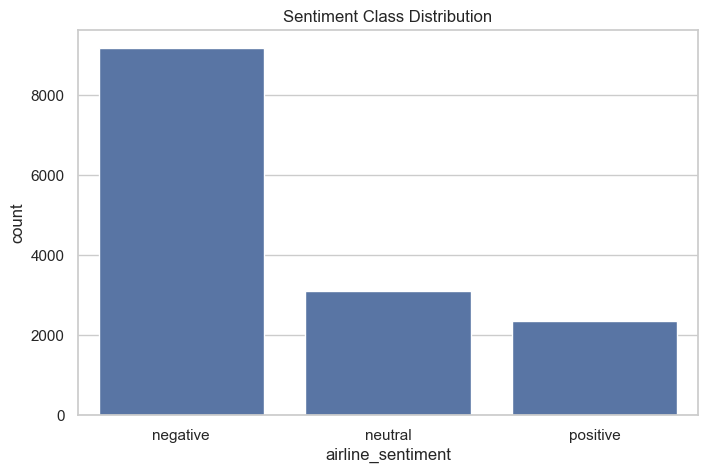

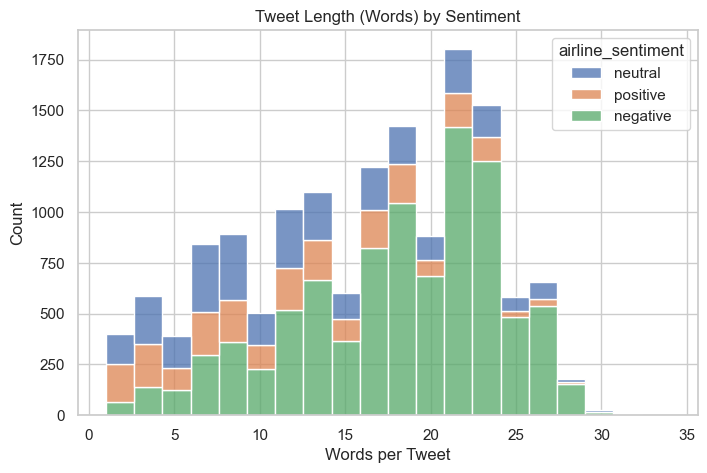

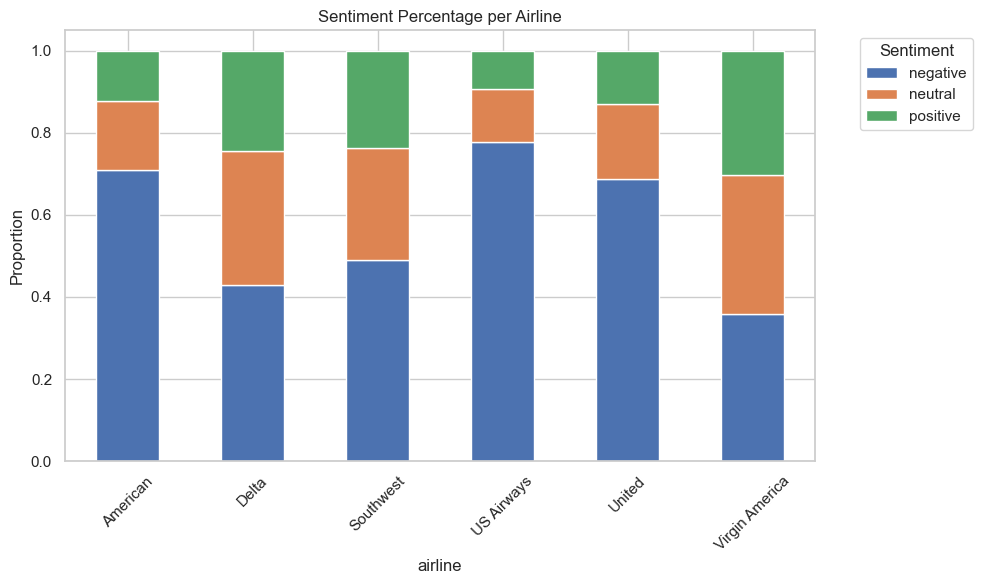

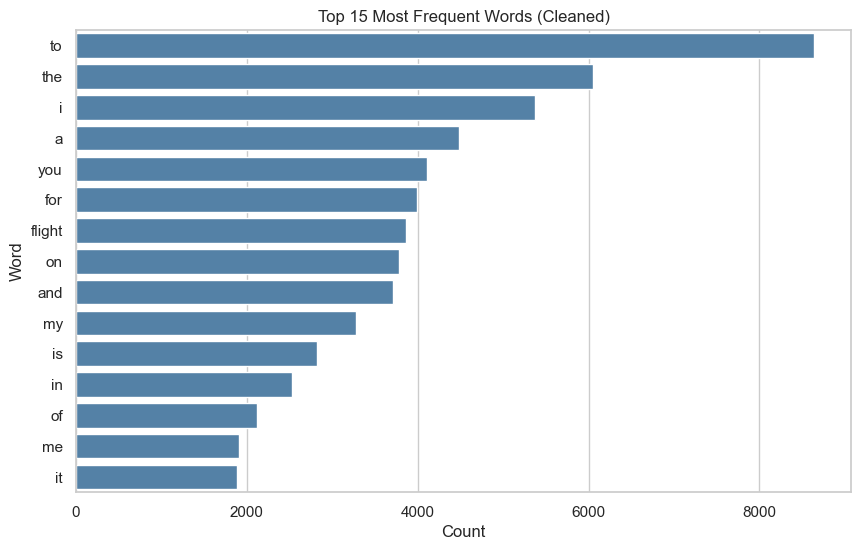

Vocabulary Size: 6106
Data preparation and EDA complete.


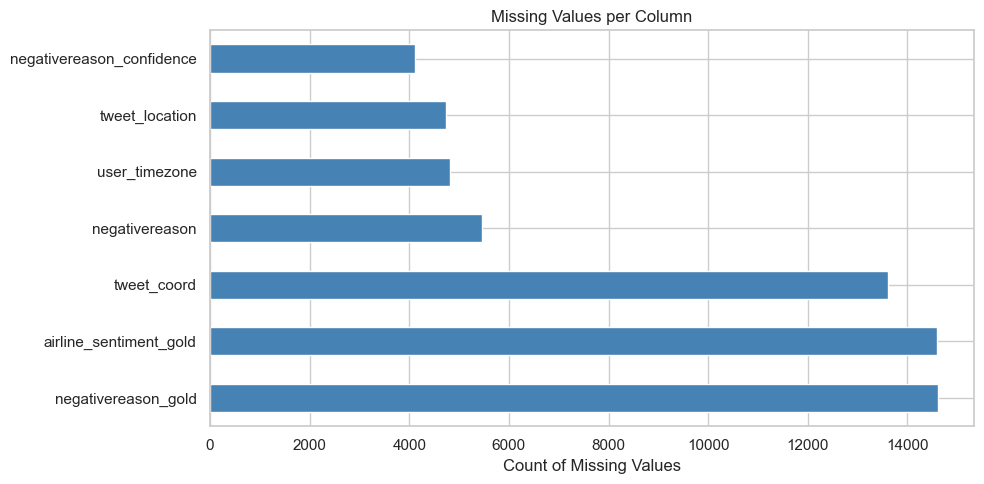

In [2]:

# configurar colores y estilo visual de los graficos
sns.set_theme(style="whitegrid")

# definir valores fijos para el largo y la frecuencia del texto
MIN_WORD_FREQ = 2
MAX_SEQ_LENGTH = 30

# Descargar y preparar las stopwords quitando las negaciones
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))
negaciones = {'not', 'no', 'nor', 'never', 'none', 'neither', 'cannot', 'isn', 'aren', 'wasnt', 'werent', 'hasn', 'haven', 'hadnt', 'doesn', 'don', 'didn', 'won', 'wouldn', 'shan', 'shouldn', 'couldn', 'mustn'}
stop_words = stop_words - negaciones

# funcion para limpiar el texto de enlaces y simbolos raros
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# FUncion para crear un diccionario con las palabras mas frecuentes
def build_vocab(texts, min_freq=MIN_WORD_FREQ):
    word_counter = Counter()
    for text in texts:
        word_counter.update(text.split())

    vocab = {word: idx + 2 for idx, (word, count) in enumerate(
        [(w, c) for w, c in word_counter.items() if c >= min_freq]
    )}
    vocab['<PAD>'], vocab['<UNK>'] = 0, 1
    return vocab

#funcion para convertir las palabras de los textos a numeros
def text_to_sequence(text, vocab, max_length=MAX_SEQ_LENGTH):
    words = text.split()
    sequence = [vocab.get(word, vocab['<UNK>']) for word in words]
    if len(sequence) < max_length:
        return sequence + [vocab['<PAD>']] * (max_length - len(sequence))
    return sequence[:max_length]


df = pd.read_csv("dataset/Tweets.csv")

# # limpiar todos los textos y contar cuantas palabras tiene cada uno
df['cleaned_text'] = df['text'].apply(clean_text)
df['word_count'] = df['cleaned_text'].str.split().str.len()

#Crear el diccionario final y convertir los textos a secuencias
vocab = build_vocab(df['cleaned_text'])
df['sequences'] = df['cleaned_text'].apply(lambda x: text_to_sequence(x, vocab))

print(f"# Total de tweets: {len(df)}")
print(f"# Clases: {df['airline_sentiment'].value_counts().to_dict()}")

# mostrar un grafico con la cantidad de cada sentimiento
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='airline_sentiment', order=['negative', 'neutral', 'positive'])
plt.title("Sentiment Class Distribution")
plt.show()
#Grafico sobre el largo de los textos agrupado por emocion
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='word_count', hue='airline_sentiment', multiple="stack", bins=20)
plt.title("Tweet Length (Words) by Sentiment")
plt.xlabel("Words per Tweet")
plt.show()
#grafico de emociones por cada aerolinea distinta
airline_sentiment = pd.crosstab(df['airline'], df['airline_sentiment'], normalize='index')
airline_sentiment.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title("Sentiment Percentage per Airline")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.legend(title="Sentiment", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


#Grafico con las quince palabras que mas se repiten
all_words = [word for text in df['cleaned_text'] for word in text.split()]
top_15 = pd.DataFrame(Counter(all_words).most_common(15), columns=['Word', 'Count'])

plt.figure(figsize=(10, 6))
sns.barplot(data=top_15, x='Count', y='Word', color='steelblue')
plt.title("Top 15 Most Frequent Words (Cleaned)")
plt.show()

print(f"Vocabulary Size: {len(vocab)}")
print("Data preparation and EDA complete.")
#Grafico con los datos que faltan en algunas columnas
miss = df.isnull().sum()
miss = miss[miss > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
miss.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Count of Missing Values')
ax.set_title('Missing Values per Column')
plt.tight_layout()
plt.show()

In [3]:
class TwitterDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_length=MAX_SEQ_LENGTH, already_encoded=False):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_length = max_length
        self.already_encoded = already_encoded

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        if self.already_encoded:
            sequence = torch.tensor(self.texts[idx], dtype=torch.long)
        else:
            sequence = torch.tensor(
                text_to_sequence(text, self.vocab, self.max_length),
                dtype=torch.long
            )
        return sequence, label


class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, dropout):
        super(RNNClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, n_layers, batch_first=True, dropout=dropout if n_layers > 1 else 0)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, text):
        embedded = self.dropout(self.embedding(text))
        output, hidden = self.rnn(embedded)
        hidden = self.dropout(hidden[-1])
        return self.fc(hidden)


class GRUClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, dropout):
        super(GRUClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        #self.gru = nn.GRU(embedding_dim, hidden_dim, n_layers, batch_first=True, dropout=dropout if n_layers > 1 else 0)
        #Añadimos bidericcionalidad a la GRU para que pueda leer el texto en ambos sentidos y entender mejor el contexto
        self.gru = nn.GRU(embedding_dim, hidden_dim, num_layers=n_layers,
                          batch_first=True, dropout=dropout, bidirectional=True)
        #Multiplicamos hidden_dim por 2 porque al ser bidireccional se concatenan los estados ocultos de ambas direcciones
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, text):
        embedded = self.dropout(self.embedding(text))
        output, hidden = self.gru(embedded)
        # Tomamos el último estado oculto para clasificar
        if self.gru.bidirectional:
            # Concatena el estado oculto de la dirección forward y backward
            hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        else:
            hidden = hidden[-1,:,:]

        hidden = self.dropout(hidden)
        return self.fc(hidden)


class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, num_layers, dropout):
        super().__init__()  # Inicializa la clase base de PyTorch

        # 1. Capa de Embedding
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        # 2. CAPA CORREGIDA: Definimos "self.lstm" que era lo que faltaba
        # Nota: Usamos batch_first=True asumiendo que tus datos vienen como (batch_size, seq_len)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )

        # 3. Capas de Dropout y Lineal (FC)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, text):
        # Pasar el texto por el embedding y dropout
        embedded = self.dropout(self.embedding(text))

        # Ahora "self.lstm" ya existe y no dará AttributeError
        output, (hidden, cell) = self.lstm(embedded)

        # Tomamos el último estado oculto (hidden) de la LSTM para la clasificación
        hidden = self.dropout(hidden[-1])

        # Capa final totalmente conectada
        return self.fc(hidden)

#Funcion para entrenar el modelo por una sola epoca de datos
def train_epoch(model, iterator, optimizer, criterion, device):
    model.train()
    epoch_loss = 0
    epoch_acc = 0
    for batch_idx, (text, labels) in enumerate(iterator):
        text = text.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        predictions = model(text)
        loss = criterion(predictions, labels)
        acc = (predictions.argmax(1) == labels).float().mean()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        epoch_acc += acc.item()
    return epoch_loss / len(iterator), epoch_acc / len(iterator)

#Funcion para probar y evaluar como funciona el modelo actual
def evaluate(model, iterator, criterion, device):
    model.eval()
    epoch_loss = 0
    epoch_acc = 0
    with torch.no_grad():
        for text, labels in iterator:
            text = text.to(device)
            labels = labels.to(device)
            predictions = model(text)
            loss = criterion(predictions, labels)
            acc = (predictions.argmax(1) == labels).float().mean()
            epoch_loss += loss.item()
            epoch_acc += acc.item()
    return epoch_loss / len(iterator), epoch_acc / len(iterator)


# funcion general para entrenar el modelo por varias epocas completas
def train_model(model, train_iterator, val_iterator, optimizer, criterion, epochs, model_name):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0
    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_iterator, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_iterator, criterion, device)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'best_{model_name}.pt')
    return history

#Funcion para obtener las predicciones finales que hace el modelo
def get_predictions(model, iterator, device):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for text, labels in iterator:
            text = text.to(device)
            predictions = model(text)
            preds = predictions.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)

In [4]:
# Carga y preparacion de datos
df = pd.read_csv('dataset/Tweets.csv')

# Usar solo tweets con sentimiento definido
df = df[df['airline_sentiment'].notna()].copy()
df = df[df['text'].notna()].copy()

# Codificar etiquetas
le = LabelEncoder()
df['sentiment_encoded'] = le.fit_transform(df['airline_sentiment'])
classes = le.classes_
num_classes = len(classes)

# Limpiar textos
df['text_cleaned'] = df['text'].apply(clean_text)

# Construir vocabulario
vocab = build_vocab(df['text_cleaned'], min_freq=MIN_WORD_FREQ)
vocab_size = len(vocab)

# Dividir datos
X_train, X_temp, y_train, y_temp = train_test_split(
    df['text_cleaned'].values,
    df['sentiment_encoded'].values,
    test_size=0.3,
    random_state=42,
    stratify=df['sentiment_encoded'].values
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

# Convertir textos a secuencias numéricas (entrenamiento)
X_train_seq = np.array([text_to_sequence(t, vocab) for t in X_train])

# SMOTE: balanceo del conjunto de entrenamiento
sm = SMOTE(random_state=42)
X_train_seq, y_train = sm.fit_resample(X_train_seq, y_train)

# Crear datasets
train_dataset = TwitterDataset(X_train_seq, y_train, vocab, already_encoded=True)
val_dataset = TwitterDataset(X_val, y_val, vocab)
test_dataset = TwitterDataset(X_test, y_test, vocab)



In [5]:
# Preparación final de datos

df = df[df['airline_sentiment'].notna()].copy()
df = df[df['text'].notna()].copy()

le = LabelEncoder()
df['sentiment_encoded'] = le.fit_transform(df['airline_sentiment'])
classes = le.classes_
num_classes = len(classes)

df['text_cleaned'] = df['text'].apply(clean_text)

vocab = build_vocab(df['text_cleaned'], min_freq=MIN_WORD_FREQ)
vocab_size = len(vocab)

X_train, X_temp, y_train, y_temp = train_test_split(
    df['text_cleaned'].values, df['sentiment_encoded'].values,
    test_size=0.3, random_state=42, stratify=df['sentiment_encoded'].values
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

X_train_seq = np.array([text_to_sequence(t, vocab) for t in X_train])

sm = SMOTE(random_state=42)
X_train_seq, y_train = sm.fit_resample(X_train_seq, y_train)

train_dataset = TwitterDataset(X_train_seq, y_train, vocab, already_encoded=True)
val_dataset = TwitterDataset(X_val, y_val, vocab)
test_dataset = TwitterDataset(X_test, y_test, vocab)

# calcular el peso real de las clases para equilibrar mejor el modelo
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

#Definir una funcion de perdida especial para corregir los errores
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = nn.CrossEntropyLoss(reduction='none')(inputs, targets)
        p_t = torch.exp(-ce_loss)
        focal_loss = (1 - p_t) ** self.gamma * ce_loss
        if self.alpha is not None:
            focal_loss = self.alpha[targets] * focal_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        return focal_loss.sum()


criterion = FocalLoss(alpha=class_weights, gamma=2.0)
print(f"# Pesos de clases: {dict(zip(classes, class_weights.cpu().numpy()))}")

# Pesos de clases: {'negative': np.float32(1.0), 'neutral': np.float32(1.0), 'positive': np.float32(1.0)}


In [6]:

N_TRIALS = 20
OPTUNA_EPOCHS = 8


def objective(trial):
    arch = trial.suggest_categorical("architecture", ["RNN", "GRU", "LSTM"])
    emb_dim = trial.suggest_categorical("embedding_dim", [64, 128, 256])
    hid_dim = trial.suggest_categorical("hidden_dim", [64, 128, 256])
    n_layers = trial.suggest_int("num_layers", 1, 3)
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    lr = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    bs = trial.suggest_categorical("batch_size", [64, 128])

    cls_map = {"RNN": RNNClassifier, "GRU": GRUClassifier, "LSTM": LSTMClassifier}
    model = cls_map[arch](vocab_size, emb_dim, hid_dim, num_classes, n_layers, dropout).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=bs, shuffle=False)

    best_val_acc = 0.0
    for epoch in range(OPTUNA_EPOCHS):
        train_epoch(model, train_loader, optimizer, criterion, device)
        _, val_acc = evaluate(model, val_loader, criterion, device)
        best_val_acc = max(best_val_acc, val_acc)
        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return best_val_acc


#Hacer una pequeña prueba rapida para estimar cuanto tiempo va a tardar
train_loader_temp = DataLoader(train_dataset, batch_size=64, shuffle=True)
t0 = time.time()
_m = GRUClassifier(vocab_size, 128, 128, num_classes, 2, 0.3).to(device)
train_epoch(_m, train_loader_temp, optim.Adam(_m.parameters()), criterion, device)
t_epoch = time.time() - t0
print(f"Tiempo estimado: {t_epoch * 5 * N_TRIALS / 60:.0f}–{t_epoch * 8 * N_TRIALS / 60:.0f} min en CPU")


Tiempo estimado: 56–89 min en CPU


In [7]:

# Estudio
study = optuna.create_study(
    direction="maximize",
    storage="sqlite:///optuna_study.db",
    study_name="sentiment",
    load_if_exists=True,
    pruner=optuna.pruners.MedianPruner()
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)



[I 2026-05-15 22:21:10,758] Using an existing study with name 'sentiment' instead of creating a new one.


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-05-15 22:31:58,394] Trial 16 finished with value: 0.7606770826710595 and parameters: {'architecture': 'GRU', 'embedding_dim': 64, 'hidden_dim': 256, 'num_layers': 3, 'dropout': 0.37788379274561884, 'learning_rate': 0.00339088616698848, 'batch_size': 128}. Best is trial 14 with value: 0.7669270833333334.
[I 2026-05-15 22:32:14,122] Trial 17 pruned. 
[I 2026-05-15 22:34:32,744] Trial 18 finished with value: 0.7770833339956071 and parameters: {'architecture': 'GRU', 'embedding_dim': 64, 'hidden_dim': 256, 'num_layers': 1, 'dropout': 0.2537625356455452, 'learning_rate': 0.004695367048662512, 'batch_size': 128}. Best is trial 18 with value: 0.7770833339956071.
[I 2026-05-15 22:36:53,573] Trial 19 pruned. 
[I 2026-05-15 22:38:58,359] Trial 20 finished with value: 0.7628472215599484 and parameters: {'architecture': 'GRU', 'embedding_dim': 256, 'hidden_dim': 128, 'num_layers': 1, 'dropout': 0.21852011223698725, 'learning_rate': 0.004856953612250642, 'batch_size': 128}. Best is trial 18

In [7]:
# Aqui tuve que reiniciar el codigo asi que perdi todo lo que ya habia ejecutado y lo pongo como constantes de la optimizacion para no tener que volver a ejecutar el estudio de optuna

print("Mejor val_accuracy: 0.77708")
print("Mejores hiperparámetros: {'architecture': 'GRU', 'embedding_dim': 64, 'hidden_dim': 256, 'num_layers': 1, 'dropout': 0.2537625356455452, 'learning_rate': 0.004695367048662512, 'batch_size': 128}")

# empezar formalmente el entrenamiento final usando los mejores parametros
print("Iniciar entrenamiento con mejores parametros")

# extraer y guardar los parametros ganadores en nuevas variables
EMBEDDING_DIM = 64
HIDDEN_DIM = 256
NUM_LAYERS = 1
DROPOUT = 0.2537625356455452
LEARNING_RATE = 0.004695367048662512
BATCH_SIZE = 128
EPOCHS = 10

# preparar de forma final los datos en lotes para comenzar a entrenar
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

results = {}

Mejor val_accuracy: 0.77708
Mejores hiperparámetros: {'architecture': 'GRU', 'embedding_dim': 64, 'hidden_dim': 256, 'num_layers': 1, 'dropout': 0.2537625356455452, 'learning_rate': 0.004695367048662512, 'batch_size': 128}
Iniciar entrenamiento con mejores parametros


In [8]:
# RNN
print("\nEntrenando a RNN")
model_rnn = RNNClassifier(vocab_size, EMBEDDING_DIM, HIDDEN_DIM, num_classes, NUM_LAYERS, DROPOUT).to(device)
optimizer_rnn = optim.Adam(model_rnn.parameters(), lr=LEARNING_RATE)
history_rnn = train_model(model_rnn, train_loader, val_loader, optimizer_rnn, criterion, EPOCHS, 'RNN')
results['RNN'] = history_rnn

# GRU
print("Entrenando a GRU")
model_gru = GRUClassifier(vocab_size, EMBEDDING_DIM, HIDDEN_DIM, num_classes, NUM_LAYERS, DROPOUT).to(device)

optimizer_gru = optim.Adam(model_gru.parameters(), lr=LEARNING_RATE)

history_gru = train_model(model_gru, train_loader, val_loader, optimizer_gru, criterion, EPOCHS, 'GRU')
results['GRU'] = history_gru

# LSTM

print("Entrenando LSTM")

model_lstm = LSTMClassifier(vocab_size, EMBEDDING_DIM, HIDDEN_DIM, num_classes, NUM_LAYERS, DROPOUT).to(device)

optimizer_lstm = optim.Adam(model_lstm.parameters(), lr=LEARNING_RATE)

history_lstm = train_model(model_lstm, train_loader, val_loader, optimizer_lstm, criterion, EPOCHS, 'LSTM')
results['LSTM'] = history_lstm


Entrenando a RNN
Entrenando a GRU
ENTRENANDO LSTM


Evaluando modelos en test

RNN:
  accuracy:  0.4390
  precision: 0.4781
  recall:    0.4390
  f1-score:  0.4532

GRU:
  accuracy:  0.7623
  precision: 0.7591
  recall:    0.7623
  f1-score:  0.7605

LSTM:
  accuracy:  0.7646
  precision: 0.7549
  recall:    0.7646
  f1-score:  0.7521
Generando gráficas de resultados...


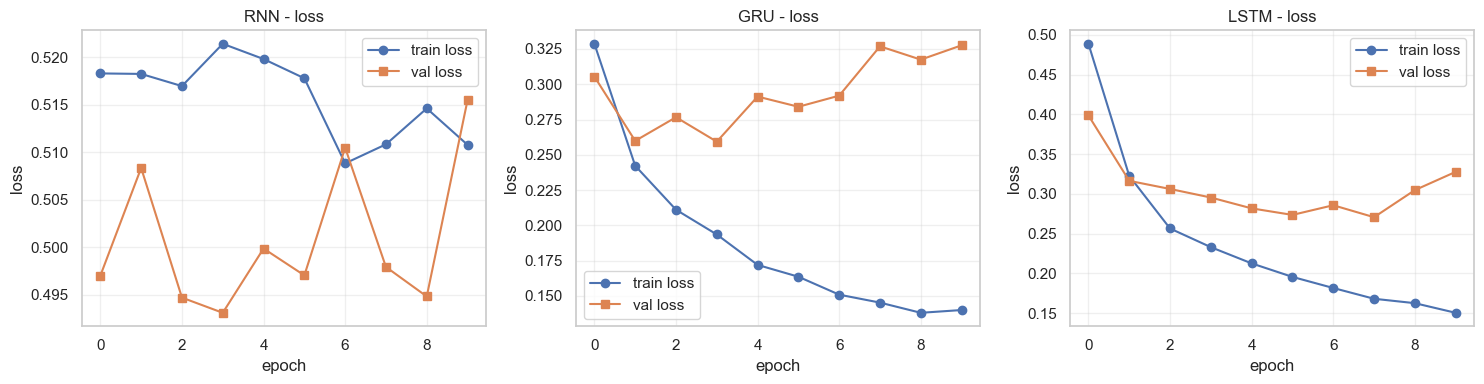

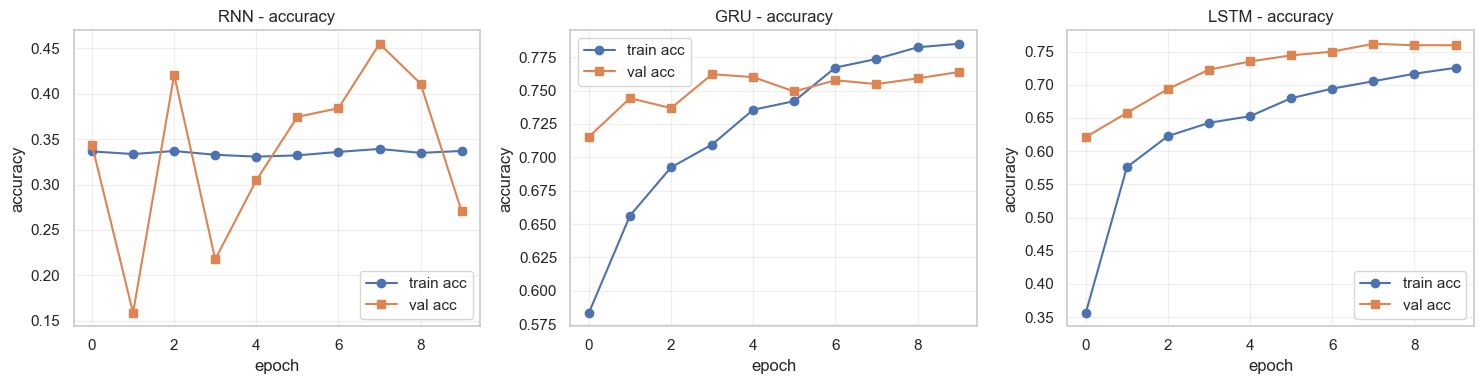

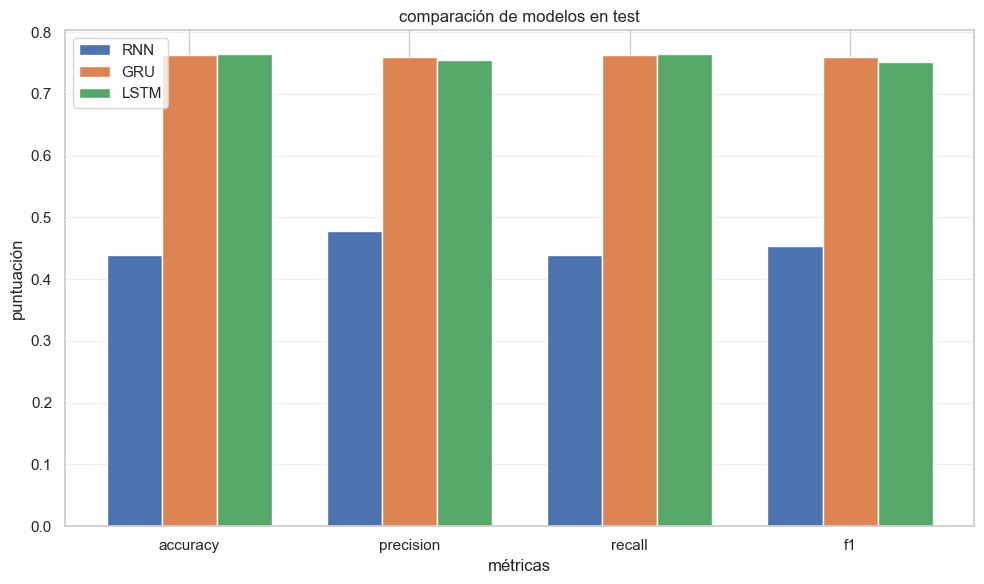

In [9]:
# Cargar los datos de prueba
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Evaluar los modelos
print("Evaluando modelos en test")
models = {'RNN': model_rnn, 'GRU': model_gru, 'LSTM': model_lstm}
test_results = {}

#Cargar formulas de metricas
from sklearn.metrics import precision_score, recall_score, f1_score

#Calcular metricas para cada red
for model_name, model in models.items():
    model.load_state_dict(torch.load(f'best_{model_name}.pt'))
    preds, labels = get_predictions(model, test_loader, device)

    accuracy = (preds == labels).mean()
    precision = precision_score(labels, preds, average='weighted')
    recall = recall_score(labels, preds, average='weighted')
    f1 = f1_score(labels, preds, average='weighted')

    test_results[model_name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

    print(f"\n{model_name}:")
    print(f"  accuracy:  {accuracy:.4f}")
    print(f"  precision: {precision:.4f}")
    print(f"  recall:    {recall:.4f}")
    print(f"  f1-score:  {f1:.4f}")

# Graficos
print("Generando gráficas de resultados...")

#Grafico de error
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, (model_name, history) in enumerate(results.items()):
    ax = axes[idx]
    ax.plot(history['train_loss'], label='train loss', marker='o')
    ax.plot(history['val_loss'], label='val loss', marker='s')
    ax.set_title(f'{model_name} - loss')
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#Grafico de aciertos
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, (model_name, history) in enumerate(results.items()):
    ax = axes[idx]
    ax.plot(history['train_acc'], label='train acc', marker='o')
    ax.plot(history['val_acc'], label='val acc', marker='s')
    ax.set_title(f'{model_name} - accuracy')
    ax.set_xlabel('epoch')
    ax.set_ylabel('accuracy')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#Grafico comparativo final
fig, ax = plt.subplots(figsize=(10, 6))
metrics = list(test_results[list(test_results.keys())[0]].keys())
x = np.arange(len(metrics))
width = 0.25

for idx, (model_name, scores) in enumerate(test_results.items()):
    values = [scores[metric] for metric in metrics]
    ax.bar(x + idx * width, values, width, label=model_name)

ax.set_xlabel('métricas')
ax.set_ylabel('puntuación')
ax.set_title('comparación de modelos en test')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [10]:
#Resumen final simple
best_model = max(test_results.items(), key=lambda x: x[1]['accuracy'])

print("\n--- reporte y conclusiones ---")
resumen = (
    f"Probamos tres redes para leer textos: rnn, gru y lstm.\n"
    f"La rnn es veloz pero olvida el contexto largo. La gru es un buen punto medio.\n"
    f"La lstm es más lenta pero recuerda mejor las frases largas.\n\n"
    f"El mejor modelo fue {best_model[0]} con un {best_model[1]['accuracy']:.4f} de acierto.\n"
    f"Los gráficos muestran cómo aprendió cada red y logramos predecir tonos en textos nuevos."
)
print(resumen)


#Funcion para adivinar el tono de un texto nuevo
def predict_sentiment(text, model, vocab, device):
    model.eval()
    cleaned_text = clean_text(text)
    sequence = torch.tensor(text_to_sequence(cleaned_text, vocab), dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(sequence)
        pred = output.argmax(1).item()

    return classes[pred]


# probar textos de prueba
print("Probando el modelo lstm con textos inventados:")
test_tweets = [
    "Great flight! Very happy with the service",
    "The flight was cancelled, terrible experience",
    "Normal flight, nothing special",
    "Neutral experience",
    "horrible flight",
    "not so great experience",
    "not so great experience, actually it has horrible and very bad"
]

# Mostrar resultados
for tweet in test_tweets:
    sentiment = predict_sentiment(tweet, model_lstm, vocab, device)
    print(f"tweet: '{tweet}' -> tono: {sentiment}")

print("\nFin del programa. los archivos y modelos se guardaron bien.")


--- reporte y conclusiones ---
Probamos tres redes para leer textos: rnn, gru y lstm.
La rnn es veloz pero olvida el contexto largo. La gru es un buen punto medio.
La lstm es más lenta pero recuerda mejor las frases largas.

El mejor modelo fue LSTM con un 0.7646 de acierto.
Los gráficos muestran cómo aprendió cada red y logramos predecir tonos en textos nuevos.
Probando el modelo lstm con textos inventados:
tweet: 'Great flight! Very happy with the service' -> tono: positive
tweet: 'The flight was cancelled, terrible experience' -> tono: negative
tweet: 'Normal flight, nothing special' -> tono: positive
tweet: 'Neutral experience' -> tono: neutral
tweet: 'horrible flight' -> tono: neutral
tweet: 'not so great experience' -> tono: positive
tweet: 'not so great experience, actually it has horrible and very bad' -> tono: positive
tweet: 'actually it has horrible and very bad, not so good experience' -> tono: positive
tweet: 'the crew were so amicable' -> tono: positive

Fin del programa